# Oasis Infobyte Data Analytics Internship

## House Price Prediction using Linear Regression

### Objective

The objective of this project is to build and evaluate a Linear Regression model to predict house prices using property-related features from the Ames Housing dataset.

The analysis covers exploratory data analysis, feature selection, missing-value handling, categorical encoding, model training, evaluation, prediction analysis, residual analysis, and coefficient interpretation.

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Dataset Loading and Initial Exploration

The Ames Housing dataset contains information about residential properties and their characteristics. The target variable, `SalePrice`, represents the final sale price of each house.

The initial exploration will examine the dataset dimensions, column names, data types, missing values, and sample records. This helps identify the preprocessing requirements before building the prediction model.

In [2]:
# ==========================================================
# Load and Inspect Ames Housing Dataset
# ==========================================================

df = pd.read_csv("AmesHousing.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

Dataset loaded successfully!
Shape: (2930, 82)

First 5 rows:


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900



Column names:
['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Driv

,0
Order,int64
PID,int64
MS SubClass,int64
MS Zoning,object
Lot Frontage,float64
...,...
Mo Sold,int64
Yr Sold,int64
Sale Type,object
Sale Condition,object



Missing values:


,0
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
Fireplace Qu,1422
Lot Frontage,490
Garage Qual,159
Garage Yr Blt,159
Garage Cond,159


### Initial Inspection – Observation

The dataset contains residential property records with numerical and categorical features. The initial inspection helps identify missing values and the different data types present in the dataset.

The `SalePrice` variable will be used as the target variable, while suitable property characteristics will be selected as predictors for the Linear Regression model.

## 2. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution and characteristics of the target variable, `SalePrice`.

Descriptive statistics will be used to examine the central tendency and spread of house prices. A distribution plot will then be used to identify skewness, concentration, and potential extreme values in house prices.

In [3]:
# ==========================================================
# Descriptive Statistics of SalePrice
# ==========================================================

print("Descriptive Statistics for SalePrice:")

display(df["SalePrice"].describe())

Descriptive Statistics for SalePrice:


,SalePrice
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


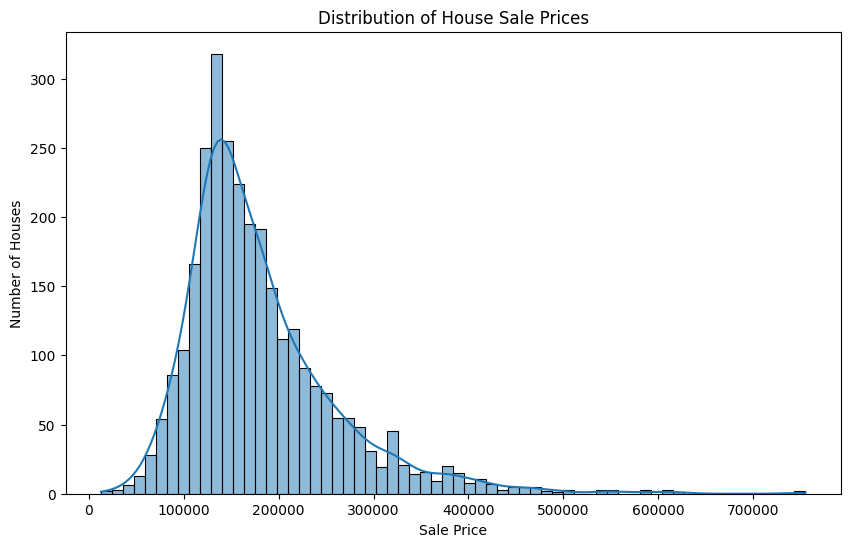

In [4]:
# ==========================================================
# Distribution of SalePrice
# ==========================================================

plt.figure(figsize=(10, 6))

sns.histplot(df["SalePrice"], kde=True)

plt.title("Distribution of House Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")

plt.show()

### SalePrice Distribution – Observation

The average house sale price is approximately $180,796, while the median price is $160,000. Since the mean is higher than the median, the SalePrice distribution is positively (right) skewed.

Most properties have sale prices concentrated between approximately $100,000 and $250,000, while a smaller number of high-priced properties extend beyond $400,000. The maximum recorded sale price is $755,000.

This variation indicates that property characteristics such as overall quality, living area, location, and other structural features are likely to be important predictors of SalePrice.

## 3. Feature Selection Discussion

Several property characteristics are expected to have a strong relationship with house sale prices.

The main candidate predictors are:

- **Overall Qual** – represents the overall material and finish quality of the house and is expected to strongly influence price.
- **Gr Liv Area** – represents above-ground living area; larger homes generally have higher prices.
- **Total Bsmt SF** – measures basement area and may contribute to the total value of a property.
- **Garage Cars** – represents garage capacity and can be associated with property value.
- **Garage Area** – measures garage size.
- **Year Built** – newer properties may have higher prices due to modern construction and condition.
- **1st Flr SF** – represents first-floor living area.
- **Full Bath** – the number of full bathrooms can influence buyer preferences and property value.
- **TotRms AbvGrd** – represents the number of rooms above ground and provides an indication of house size.

These features were selected because they represent important aspects of property size, quality, age, and amenities. Correlation analysis will be used next to identify which numerical features have the strongest relationship with SalePrice.

In [5]:
# ==========================================================
# Correlation Analysis
# ==========================================================

# Select numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Calculate correlations with SalePrice
saleprice_corr = numeric_df.corr()["SalePrice"].sort_values(ascending=False)

print("Top numerical features correlated with SalePrice:")
display(saleprice_corr.head(11))

Top numerical features correlated with SalePrice:


,SalePrice
SalePrice,1.000000
Overall Qual,0.799262
Gr Liv Area,0.706780
Garage Cars,0.647877
Garage Area,0.640401
Total Bsmt SF,0.632280
1st Flr SF,0.621676
Year Built,0.558426
Full Bath,0.545604
Year Remod/Add,0.532974


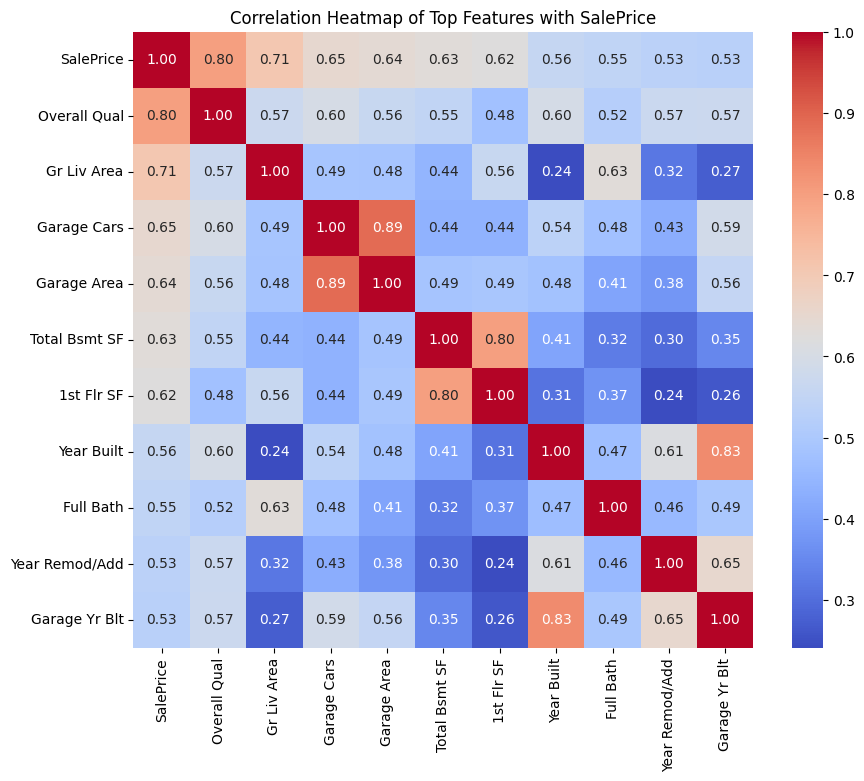

In [6]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

top_features = saleprice_corr.head(11).index

plt.figure(figsize=(10, 8))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Top Features with SalePrice")
plt.show()

### Correlation Analysis – Observation

The correlation analysis shows that `Overall Qual` has the strongest positive correlation with `SalePrice`, with a correlation coefficient of approximately 0.80. This indicates that overall house quality is strongly associated with sale price.

Other important positively correlated features include `Gr Liv Area` (0.71), `Garage Cars` (0.65), `Garage Area` (0.64), `Total Bsmt SF` (0.63), and `1st Flr SF` (0.62).

These results support the earlier feature-selection discussion. However, correlation only measures linear relationships between numerical variables and does not capture the full effect of categorical features. Therefore, both numerical and categorical predictors will be considered when building the Linear Regression model.

## 4. Data Preprocessing

Before training the Linear Regression model, the dataset must be prepared by handling missing values and converting categorical variables into numerical form.

Numerical missing values will be imputed using the median, while categorical missing values will be imputed using the most frequent category. Categorical features will then be transformed using One-Hot Encoding so that they can be used by the machine-learning model.

In [7]:
# ==========================================================
# Prepare Features and Target
# ==========================================================

X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

# Remove identifier columns that are not useful predictors
X = X.drop(columns=["Order", "PID"])

print("Features:", X.shape)
print("Target:", y.shape)

Features: (2930, 79)
Target: (2930,)


## 5. Train-Test Split

The dataset is divided into training and testing sets using an 80/20 split.

The training set is used to learn the relationship between the property features and SalePrice, while the testing set is kept separate and used to evaluate how well the trained model performs on unseen data.

A fixed random state is used to make the results reproducible.

In [8]:
# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (2344, 79)
Testing features: (586, 79)
Training target: (2344,)
Testing target: (586,)


## 6. Missing Value Handling and One-Hot Encoding

The dataset contains both numerical and categorical features with missing values.

For numerical features, missing values are replaced using the median of the training data. For categorical features, missing values are replaced using the most frequent category.

Categorical variables are then converted into numerical variables using One-Hot Encoding. The preprocessing is fitted only on the training data to avoid data leakage and ensure a fair evaluation on the test set.

In [9]:
# ==========================================================
# Identify Numerical and Categorical Features
# ==========================================================

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 36
Number of categorical features: 43


In [10]:
# ==========================================================
# Create Preprocessing Pipelines
# ==========================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


## 7. Linear Regression Model

Linear Regression is used to model the relationship between the selected house features and `SalePrice`.

The preprocessing pipeline handles missing values and converts categorical variables into numerical representations before the Linear Regression model is trained.

The model is trained only on the training data and then used to predict prices for the unseen test data.

In [11]:
# ==========================================================
# Build and Train Linear Regression Model
# ==========================================================

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [12]:
# ==========================================================
# Generate Predictions
# ==========================================================

y_pred = linear_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

display(pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": y_pred[:10]
}))

Predictions generated successfully!
Number of predictions: 586


,Actual Price,Predicted Price
0,161000,146044.647918
1,116000,109349.488643
2,196500,186299.187332
3,123600,127674.014480
4,126000,140788.447116
5,174190,190237.052627
6,200000,159915.954468
7,148500,142139.256464
8,88750,116082.980355
9,409900,335593.537005


## 8. Model Evaluation

The Linear Regression model is evaluated using three metrics:

- **Mean Squared Error (MSE):** measures the average squared difference between actual and predicted prices. Lower values indicate better performance.
- **Root Mean Squared Error (RMSE):** is the square root of MSE and represents the prediction error in the same units as house prices. Lower values are better.
- **R² Score:** indicates how much of the variation in house prices is explained by the model. A value closer to 1 indicates better explanatory performance.

In [13]:
# ==========================================================
# Model Evaluation
# ==========================================================

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("=" * 40)
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Linear Regression Performance
Mean Squared Error (MSE): 913,015,555.88
Root Mean Squared Error (RMSE): 30,216.15
R² Score: 0.8861


### Model Evaluation – Observation

The Linear Regression model achieved an R² score of 0.8861, indicating that approximately 88.61% of the variation in house sale prices is explained by the selected property features.

The RMSE is approximately $30,216, meaning that the model's predictions differ from the actual house prices by about $30,216 on average in terms of the RMSE measure.

The model therefore provides a reasonably strong baseline for predicting house prices, although some prediction errors remain, particularly for properties with unusual or very high sale prices.

## 9. Actual vs. Predicted House Prices

An actual-versus-predicted scatter plot is used to visually evaluate the model's predictions. If the model predicts accurately, the points should lie close to the diagonal reference line, where predicted price equals actual price.

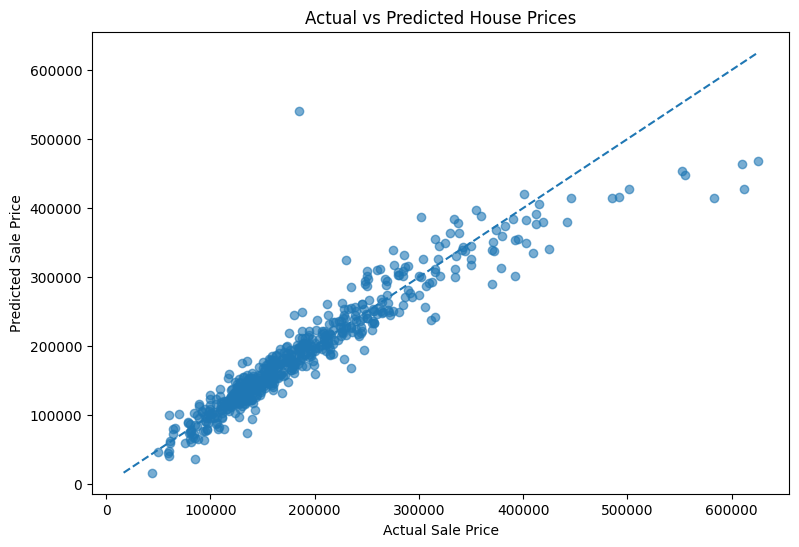

In [14]:
# ==========================================================
# Actual vs Predicted Prices
# ==========================================================

plt.figure(figsize=(9, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Reference line
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.show()

### Actual vs. Predicted – Observation

The scatter plot compares the actual house prices with the prices predicted by the Linear Regression model. Points closer to the diagonal reference line represent more accurate predictions.

The overall clustering around the reference line indicates that the model captures the general relationship between property characteristics and sale prices. Greater deviations from the line represent larger prediction errors, particularly for some higher-priced properties.

## 10. Residual Analysis

Residuals represent the difference between the actual and predicted house prices. A residual plot is used to check whether the errors are randomly distributed around zero.

A random pattern around the zero line indicates that the model has captured the main relationship between the predictors and the target variable. Systematic patterns may indicate that the model could be improved.

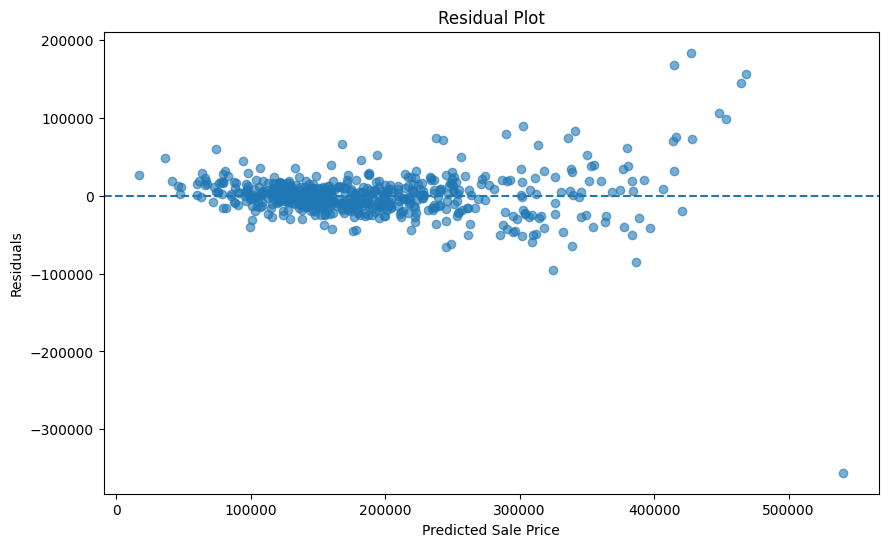

In [15]:
# ==========================================================
# Residual Plot
# ==========================================================

residuals = y_test - y_pred

plt.figure(figsize=(10, 6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")

plt.show()

### Residual Analysis – Observation

The residuals are mostly distributed around the zero reference line, indicating that the Linear Regression model captures the main relationship between the selected features and SalePrice.

However, the spread of residuals increases for higher predicted prices, and several large positive and negative residuals are visible. This indicates that the model has larger prediction errors for some high-priced properties.

Overall, there is no strong systematic pattern across the majority of observations, but the increasing spread suggests that a regularised or more flexible model may provide improved performance.

## 11. Coefficient Analysis

Linear Regression coefficients indicate how the predicted house price changes with each encoded feature while other features are held constant.

Positive coefficients indicate a positive contribution to the predicted price, while negative coefficients indicate a negative contribution. Because categorical variables are One-Hot Encoded, the model produces coefficients for the individual encoded categories as well.

In [16]:
# ==========================================================
# Linear Regression Coefficient Analysis
# ==========================================================

# Get feature names after preprocessing
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()

# Get regression coefficients
coefficients = linear_model.named_steps["regressor"].coef_

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Highest positive and negative coefficients
top_positive = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

top_negative = coefficient_df.sort_values(
    by="Coefficient",
    ascending=True
).head(10)

print("Top 10 Positive Coefficients:")
display(top_positive)

print("\nTop 10 Negative Coefficients:")
display(top_negative)

Top 10 Positive Coefficients:


,Feature,Coefficient
91,cat__Neighborhood_StoneBr,53050.131176
137,cat__Roof Matl_WdShngl,43521.206981
84,cat__Neighborhood_NoRidge,40304.740288
272,cat__Pool QC_Ex,37949.794158
281,cat__Misc Feature_Gar2,36917.209478
85,cat__Neighborhood_NridgHt,28195.249991
76,cat__Neighborhood_GrnHill,25826.652699
98,cat__Condition 1_PosN,20454.562824
141,cat__Exterior 1st_BrkFace,19134.743906
261,cat__Garage Qual_Gd,18653.786919



Top 10 Negative Coefficients:


,Feature,Coefficient
130,cat__Roof Matl_ClyTile,-49995.395219
274,cat__Pool QC_Gd,-41470.292625
280,cat__Misc Feature_Elev,-32588.313611
49,cat__Lot Shape_IR3,-27060.259307
114,cat__Bldg Type_Twnhs,-20067.845407
283,cat__Misc Feature_Shed,-18906.605383
73,cat__Neighborhood_Edwards,-17304.635089
83,cat__Neighborhood_NWAmes,-16859.939213
80,cat__Neighborhood_Mitchel,-16016.558680
260,cat__Garage Qual_Fa,-15250.509755


### Coefficient Analysis – Observation

The coefficient analysis shows that different property characteristics and categorical levels have different effects on predicted house prices.

Among the positive coefficients, `Neighborhood_StoneBr` has the largest positive coefficient at approximately $53,050, followed by `Roof Matl_WdShngl` and `Neighborhood_NoRidge`. These features are associated with higher predicted house prices relative to their respective reference categories.

Among the negative coefficients, `Roof Matl_ClyTile` has the largest negative coefficient at approximately −$49,995, followed by `Pool QC_Gd` and `Misc Feature_Elev`.

These coefficients should be interpreted as model-based effects while holding other encoded features constant. They indicate which feature categories have the strongest positive or negative contribution to the Linear Regression predictions, rather than proving direct causation.

## 12. Bonus – Ridge Regression Comparison

Ridge Regression is a regularised version of Linear Regression that adds a penalty to large coefficients. This can help reduce overfitting, especially when the dataset contains many correlated or one-hot encoded features.

The Ridge model will be trained using the same preprocessing pipeline and evaluated using MSE, RMSE, and R² so that its performance can be compared fairly with the Linear Regression model.

In [17]:
# ==========================================================
# Train Ridge Regression Model
# ==========================================================

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=10.0))
])

ridge_model.fit(X_train, y_train)

# Predictions
ridge_pred = ridge_model.predict(X_test)

# Evaluation
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Performance")
print("=" * 40)
print(f"Mean Squared Error (MSE): {ridge_mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {ridge_rmse:,.2f}")
print(f"R² Score: {ridge_r2:.4f}")

Ridge Regression Performance
Mean Squared Error (MSE): 1,224,742,131.45
Root Mean Squared Error (RMSE): 34,996.32
R² Score: 0.8472


### Ridge Regression Comparison – Observation

The Ridge Regression model achieved an R² score of 0.8472 and an RMSE of approximately $34,996.

Compared with the Linear Regression model, which achieved an R² score of 0.8861 and an RMSE of approximately $30,216, Ridge Regression performed worse on the test dataset.

Therefore, Linear Regression is selected as the final model because it provides a higher R² score and lower RMSE for this dataset.

## 13. Conclusion

This project developed an end-to-end Linear Regression model for predicting house sale prices using the Ames Housing dataset.

### Key Findings

1. The `SalePrice` variable is positively skewed, with most houses concentrated in the lower-to-middle price range.
2. `Overall Qual` showed the strongest numerical correlation with `SalePrice` at approximately 0.80, followed by `Gr Liv Area` at 0.71.
3. The Linear Regression model achieved an R² score of **0.8861** and an RMSE of approximately **$30,216**, indicating strong predictive performance on the test dataset.
4. The actual-versus-predicted plot showed that most predictions were reasonably close to the ideal diagonal line.
5. Residual analysis showed that most errors were centered around zero, although larger errors occurred for some higher-priced properties.
6. Ridge Regression performed worse than Linear Regression on this test split, with an R² of 0.8472 and an RMSE of approximately $34,996.

### Actionable Business Recommendations

1. **Prioritize overall property quality:** Since `Overall Qual` has the strongest relationship with sale price, improving construction quality, materials, and overall finish can potentially increase property value.

2. **Focus on usable living space:** `Gr Liv Area` has a strong positive relationship with price. Property developers and sellers should consider usable living area when evaluating or improving properties.

3. **Use model predictions for initial price estimation:** The Linear Regression model can be used as a baseline valuation tool to provide an initial estimate of property prices. However, high-value properties should receive additional expert review because the residual analysis shows larger errors for some expensive properties.

### Final Model

Based on the evaluation results, **Linear Regression is selected as the final model** because it achieved better performance than Ridge Regression on the test dataset.